## Импорт библиотек

In [2368]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [2369]:
warnings.filterwarnings('ignore')

## Загрузка данных

In [2370]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2371]:
# df = pd.read_csv('/content/drive/MyDrive/Colab/Курсовая, 3 курс/После обработки/ERA5_full.csv', parse_dates=['date'])
# era5 = pd.read_csv('/content/drive/MyDrive/Colab/Курсовая, 3 курс/После обработки/ERA5_full.csv', parse_dates=['date'])

In [2372]:
df = pd.read_csv('climat_official.csv', parse_dates=['date'])
era5 = pd.read_csv('ERA5_full.csv', parse_dates=['date'])

In [2373]:
df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
0,34059,1981-01-01,0.1,0.4,55.25,10.00,10.000,8.00,8.000,0.00,...,0,0,0,0,0,0,0,0,0,0
1,34152,1981-01-01,-0.1,0.4,71.00,10.00,7.500,8.00,7.000,0.00,...,0,0,0,0,0,0,0,0,0,0
2,34163,1981-01-01,-1.0,0.4,80.00,10.00,7.500,8.00,6.250,0.00,...,0,0,0,0,0,0,0,0,0,0
3,34172,1981-01-01,0.4,0.0,70.00,10.00,8.750,8.00,7.250,0.00,...,0,0,0,0,0,0,0,0,0,0
4,34186,1981-01-01,-3.6,1.0,24.50,9.75,8.625,6.25,6.375,2.25,...,0,0,0,0,0,0,0,0,0,0


In [2374]:
era5.head()

,Индекс ВМО,date,latitude,longitude,2m_dewpoint_temperature_stream-oper_daily-mean,2m_temperature_0_daily-mean,surface_pressure_0_daily-mean,total_precipitation_0_daily-mean,maximum_2m_temperature_since_previous_post_processing_0_daily-mean,skin_temperature_0_daily-mean,mean_evaporation_rate_0_daily-mean,clear_sky_direct_solar_radiation_at_surface_0_daily-mean,evaporation_0_daily-mean,potential_evaporation_0_daily-mean,convective_precipitation_0_daily-mean,avg_pevr,avg_cpr,total_precipitation_scaled
0,34059,1940-01-01,52.0,43.65,-17.98183,-15.66160,99108.64,0.006866,-15.46342,-15.76063,-6.382252e-08,143130.860,-0.000235,-0.022892,0.0,-0.006360,0.0,-0.059208
1,34059,1940-01-02,52.0,43.65,-25.21587,-22.83079,99859.69,0.000119,-22.02915,-24.17704,2.240773e-07,114577.516,0.000809,-0.005217,0.0,-0.001451,0.0,-0.231404
2,34059,1940-01-03,52.0,43.65,-28.55027,-26.00974,99506.39,0.003672,-25.81016,-27.42121,2.444089e-07,112423.450,0.000887,-0.008524,0.0,-0.002368,0.0,-0.140737
3,34059,1940-01-04,52.0,43.65,-23.95266,-21.39904,99039.92,0.145149,-21.49006,-21.82960,3.162277e-07,105748.640,0.001139,-0.017972,0.0,-0.004992,0.0,3.470007
4,34059,1940-01-05,52.0,43.65,-15.92990,-14.26237,98507.39,0.070214,-14.27793,-15.25153,1.394192e-06,113422.200,0.005017,-0.022017,0.0,-0.006115,0.0,1.557536


In [2375]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112035 entries, 0 to 112034
Data columns (total 51 columns):
 #   Column                                           Non-Null Count   Dtype         
---  ------                                           --------------   -----         
 0   Индекс ВМО                                       112035 non-null  int64         
 1   date                                             112035 non-null  datetime64[ns]
 2   Средняя температура воздуха                      112035 non-null  float64       
 3   Количество осадков                               112035 non-null  float64       
 4   Горизонтальная дальность видимости               112035 non-null  float64       
 5   Общее количество облачности                      112035 non-null  float64       
 6   Количество облачности нижнего яруса              112035 non-null  float64       
 7   Форма облаков верхнего яруса                     112035 non-null  float64       
 8   Форма облаков среднего я

In [2376]:
df.isna().sum()

Индекс ВМО                                            0
date                                                  0
Средняя температура воздуха                           0
Количество осадков                                    0
Горизонтальная дальность видимости                    0
Общее количество облачности                           0
Количество облачности нижнего яруса                   0
Форма облаков верхнего яруса                          0
Форма облаков среднего яруса                          0
Форма облаков вертикального развития                  0
Слоистые и слоисто-кучевые облака                     0
Слоисто-дожд,разорванно-дождевые облака               0
Высота нижней границы облачности                   1106
Погода между сроками                                  0
Погода в срок наблюдения                              0
Направление ветра                                     0
Средняя скорость ветра                                0
Максимальная скорость ветра                     

In [2377]:
df = df.interpolate()

In [2378]:
df.isna().sum()

Индекс ВМО                                         0
date                                               0
Средняя температура воздуха                        0
Количество осадков                                 0
Горизонтальная дальность видимости                 0
Общее количество облачности                        0
Количество облачности нижнего яруса                0
Форма облаков верхнего яруса                       0
Форма облаков среднего яруса                       0
Форма облаков вертикального развития               0
Слоистые и слоисто-кучевые облака                  0
Слоисто-дожд,разорванно-дождевые облака            0
Высота нижней границы облачности                   0
Погода между сроками                               0
Погода в срок наблюдения                           0
Направление ветра                                  0
Средняя скорость ветра                             0
Максимальная скорость ветра                        0
Сумма осадков                                 

## Разделение на тренировчную/валидационную/тестовую

In [2379]:
df.groupby('Индекс ВМО')['date'].count()

Индекс ВМО
34059    16005
34152    16005
34163    16005
34172    16005
34186    16005
34289    16005
34391    16005
Name: date, dtype: int64

На каждый индекс станции есть день

In [2380]:
df.shape

(112035, 51)

In [2381]:
df.date.min(), df.date.max()

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-10-26 00:00:00'))

In [2382]:
# границы
test_start = df['date'].max() - pd.DateOffset(months=1)
val_start = test_start - pd.DateOffset(months=1)
val_start, test_start

(Timestamp('2024-08-26 00:00:00'), Timestamp('2024-09-26 00:00:00'))

In [2383]:
train_df = df[df['date'] < val_start]
val_df = df[(df['date'] >= val_start) & (df['date'] < test_start)]
test_df = df[df['date'] >= test_start]

In [2384]:
train_df.shape, val_df.shape, test_df.shape

((111601, 51), (217, 51), (217, 51))

In [2385]:
217 / 7

31.0

1 месяц

### Делаем значения Nan чтобы не было утечек

In [2386]:
old_val_df = val_df.copy()  # Понадобится для восстановления

In [2387]:
test_df_nan = test_df.copy()

Всё кроме даты и индекса

In [2388]:
# cols_to_nan = [c for c in val_df.columns if c not in ['date', 'Индекс ВМО']]

cols_to_nan = [
    c for c in val_df.columns
    if c not in ['date', 'Индекс ВМО']
       and not c.endswith('_missing')
]

val_df[cols_to_nan] = np.nan
test_df_nan[cols_to_nan] = np.nan

In [2389]:
val_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
111601,34059,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111602,34152,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111603,34163,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111604,34172,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111605,34186,2024-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [2390]:
test_df_nan.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
111818,34059,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111819,34152,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111820,34163,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111821,34172,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111822,34186,2024-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1


## Добавление лагов

1️⃣ Короткие лаги

lag1, lag2, lag3 — уже есть, ловят недавние изменения

2️⃣ Средние и длинные лаги

lag7, lag14, lag30 — недельная и месячная сезонность

Если будут данные за несколько лет, можно lag365 — годовая повторяемость

3️⃣ Скользящие агрегаты

Среднее: rolling_mean_3, rolling_mean_7, rolling_mean_30

Сумма: rolling_sum_3, rolling_sum_7, rolling_sum_30 (для осадков, облачности)

Максимум/минимум: rolling_max_3, rolling_min_7

4️⃣ Разностные признаки

diff_1 = value_today - value_yesterday

diff_3, diff_7 — показывают ускорение изменения

In [2391]:
# Соеднияем всё в один датасет(Вал и тест - Nan)
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_df = train_val_df.sort_values(['Индекс ВМО', 'date'])

In [2392]:
train_val_df.date.min(), train_val_df.date.max()

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [2393]:
original_cols = [col for col in df.columns if col not in ['Индекс ВМО', 'date']]

### Общие лаги

### Функция лагов для конкретного дня

In [2394]:
def create_lags(df, index_col='Индекс ВМО', date_col='date'):
    # print(df.date.min(), df.date.max())
    # lagged_df = df.copy()
    #
    # # Выбираем колонки для лагов
    # short_lags = [1, 2, 3]
    # cols_to_short_lag = [col for col in lagged_df.columns if col not in [index_col, date_col]]
    # for lag in short_lags:
    #     for col in cols_to_short_lag:
    #         lagged_df[f'{col}_short_lag{lag}'] = lagged_df.groupby(index_col)[col].shift(lag)
    #
    # return lagged_df

    return df

In [2395]:
lagged_df = create_lags(train_val_df)
# lagged_df.tail(40)
lagged_df.tail()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
111789,34391,2024-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111796,34391,2024-09-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
111803,34391,2024-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111810,34391,2024-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1
111817,34391,2024-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1


In [2396]:
lagged_df.shape

(111818, 51)

### Удаление пропусков для начала лагов

Т.к для первых дней, лагов нет, просто удалим их

In [2397]:
# Для каждой группы находим первую дату без NaN
def first_valid_date_per_group(df, group_col='Индекс ВМО', date_col='date'):
    # Словарь: индекс ВМО - дата первой строки без NaN
    first_dates = {}

    for idx, group in df.groupby(group_col):
        # Проверяем только колонки с NaN
        valid_rows = group[~group.isna().any(axis=1)]
        if not valid_rows.empty:
            first_dates[idx] = valid_rows[date_col].iloc[0]
        else:
            first_dates[idx] = None  # если все строки пустые

    return first_dates


# Используем функцию
first_dates_dict = first_valid_date_per_group(lagged_df)
first_dates_dict

{34059: Timestamp('1981-01-01 00:00:00'),
 34152: Timestamp('1981-01-01 00:00:00'),
 34163: Timestamp('1981-01-01 00:00:00'),
 34172: Timestamp('1981-01-01 00:00:00'),
 34186: Timestamp('1981-01-01 00:00:00'),
 34289: Timestamp('1981-01-01 00:00:00'),
 34391: Timestamp('1981-01-01 00:00:00')}

In [2398]:
# Обрезаем каждую группу по дате
cleaned_groups = []
for idx, group in lagged_df.groupby('Индекс ВМО'):
    start_date = first_dates_dict[idx]
    cleaned_group = group[group['date'] >= start_date]
    cleaned_groups.append(cleaned_group)

clean_lagged_df = pd.concat(cleaned_groups).reset_index(drop=True)

In [2399]:
clean_lagged_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
0,34059,1981-01-01,0.1,0.4,55.250,10.000,10.000,8.000,8.000,0.000,...,0,0,0,0,0,0,0,0,0,0
1,34059,1981-01-02,1.6,0.5,61.000,10.000,10.000,8.000,8.000,0.000,...,0,0,0,0,0,0,0,0,0,0
2,34059,1981-01-03,-0.7,0.0,61.375,8.750,5.000,5.250,4.125,0.000,...,0,0,0,0,0,0,0,0,0,0
3,34059,1981-01-04,-2.5,0.0,52.375,8.875,5.125,5.375,4.250,1.125,...,0,0,0,0,0,0,0,0,0,0
4,34059,1981-01-05,-0.1,3.2,52.500,10.125,8.875,7.250,7.125,1.125,...,0,0,0,0,0,0,0,0,0,0


In [2400]:
clean_lagged_df.shape

(111818, 51)

## Конструирование признаков

In [2401]:
clean_lagged_df.describe()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
count,111818.000000,111818,111601.000000,111601.000000,111601.000000,111601.000000,111601.000000,111601.000000,111601.000000,111601.000000,...,111818.000000,111818.000000,111818.000000,111818.000000,111818.000000,111818.000000,111818.000000,111818.000000,111818.000000,111818.000000
mean,34201.714286,2002-11-13 12:00:00.000000128,6.893198,1.172517,87.819498,6.515082,3.217362,3.090945,2.195364,0.408341,...,0.015454,0.015454,0.015677,0.015677,0.015677,0.015972,0.015972,0.015972,0.015972,0.426801
min,34059.000000,1981-01-01 00:00:00,-31.300000,0.000000,1.375000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34152.000000,1991-12-08 00:00:00,-2.600000,0.000000,81.708333,4.000000,0.250000,0.500000,0.250000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,34172.000000,2002-11-13 12:00:00,7.500000,0.000000,96.000000,7.125000,2.250000,2.125000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,34289.000000,2013-10-20 00:00:00,17.800000,0.600000,97.500000,9.500000,5.125000,5.375000,3.500000,0.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,34391.000000,2024-09-25 00:00:00,34.300000,96.400000,99.000000,13.000000,13.000000,9.000000,9.000000,9.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23.000000
std,99.222726,NaN,12.627399,3.346020,13.584580,3.219272,3.271235,2.815102,2.494920,0.862041,...,0.123349,0.123349,0.124224,0.124224,0.124224,0.125369,0.125369,0.125369,0.125369,2.841200


In [2402]:
clean_lagged_df.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Сумма осадков_missing,Температура поверхности почвы_missing,Парциальное давление водяного пара_missing,Относительная влажность воздуха_missing,Дефицит насыщения водяного пара_missing,Атмосферное давление на уровне станции_missing,Атмосферное давление на уровне моря_missing,Характеристика барической тенденции_missing,Величина барической тенденции_missing,num_missing
0,34059,1981-01-01,0.1,0.4,55.250,10.000,10.000,8.000,8.000,0.000,...,0,0,0,0,0,0,0,0,0,0
1,34059,1981-01-02,1.6,0.5,61.000,10.000,10.000,8.000,8.000,0.000,...,0,0,0,0,0,0,0,0,0,0
2,34059,1981-01-03,-0.7,0.0,61.375,8.750,5.000,5.250,4.125,0.000,...,0,0,0,0,0,0,0,0,0,0
3,34059,1981-01-04,-2.5,0.0,52.375,8.875,5.125,5.375,4.250,1.125,...,0,0,0,0,0,0,0,0,0,0
4,34059,1981-01-05,-0.1,3.2,52.500,10.125,8.875,7.250,7.125,1.125,...,0,0,0,0,0,0,0,0,0,0


### Работа с датой

In [2403]:
# Разбор даты на год, месяц, день для clean_lagged_df
clean_lagged_df['year'] = clean_lagged_df['date'].dt.year
clean_lagged_df['month'] = clean_lagged_df['date'].dt.month
clean_lagged_df['day'] = clean_lagged_df['date'].dt.day

# Проверка
clean_lagged_df[['date', 'year', 'month', 'day']].head()

,date,year,month,day
0,1981-01-01,1981,1,1
1,1981-01-02,1981,1,2
2,1981-01-03,1981,1,3
3,1981-01-04,1981,1,4
4,1981-01-05,1981,1,5


In [2404]:
# День в году (Синус + косинус)
clean_lagged_df['day_of_year'] = clean_lagged_df['date'].dt.dayofyear

clean_lagged_df['day_of_year_sin'] = np.sin(2 * np.pi * clean_lagged_df['day_of_year'] / 365)
clean_lagged_df['day_of_year_cos'] = np.cos(2 * np.pi * clean_lagged_df['day_of_year'] / 365)

clean_lagged_df = clean_lagged_df.drop(columns='day_of_year')

In [2405]:
# Сезон (1-зима, 2-весна, 3-лето, 4-осень)
clean_lagged_df['season'] = ((clean_lagged_df['date'].dt.month % 12 + 3) // 3).astype(int)

In [2406]:
clean_lagged_df['month_sin'] = np.sin(2 * np.pi * clean_lagged_df['month'] / 12)
clean_lagged_df['month_cos'] = np.cos(2 * np.pi * clean_lagged_df['month'] / 12)

clean_lagged_df = clean_lagged_df.drop(columns=['month'])

### Средие значения признаков за все года

#### Только для температуры

In [2407]:
# Создаём колонку day_of_year без учёта года
clean_lagged_df['month_day'] = clean_lagged_df['date'].dt.strftime('%m-%d')

# Группировка по Индексу ВМО и дню-месяца
temp_mean = (
    clean_lagged_df
    .groupby(['Индекс ВМО', 'month_day'])['Средняя температура воздуха']
    .mean()
    .reset_index()
    .rename(columns={'Средняя температура воздуха': 'Средняя температура воздуха_mean_group'})
)

# Объединяем обратно с основным датасетом
clean_lagged_df = clean_lagged_df.merge(temp_mean, on=['Индекс ВМО', 'month_day'], how='left')

# Можно удалить временную колонку month_day, если не нужна
clean_lagged_df.drop(columns=['month_day'], inplace=True)

#### Для всех признаков

In [2408]:
# # Фильтруем колонки, исключая "_missing" и "num_missing"
# features_to_average = [col for col in original_cols if not col.endswith('_missing')]
#
# # Создаём колонку day-month без учёта года
# clean_lagged_df['month_day'] = clean_lagged_df['date'].dt.strftime('%m-%d')
#
# # Для каждого признака считаем среднее по группе (Индекс ВМО + day-month)
# for col in features_to_average:
#     temp_mean = (
#         clean_lagged_df
#         .groupby(['Индекс ВМО', 'month_day'])[col]
#         .mean()
#         .reset_index()
#         .rename(columns={col: f'{col}_mean_group'})
#     )
#     clean_lagged_df = clean_lagged_df.merge(temp_mean, on=['Индекс ВМО', 'month_day'], how='left')
#
# # Удаляем временную колонку
# clean_lagged_df.drop(columns=['month_day'], inplace=True)

#### Отклонение температуры этого ВМО от среднего по всем остальным ВМО в тот же день/месяц

In [2409]:
# Сначала создаём колонку month_day для группировки по дню и месяцу
clean_lagged_df['month_day'] = clean_lagged_df['date'].dt.strftime('%m-%d')

# Считаем среднее по всем ВМО для каждой даты (day+month)
mean_all_stations = (
    clean_lagged_df
    .groupby('month_day')['Средняя температура воздуха_mean_group']
    .transform('mean')
)

# Создаём новый признак: отклонение от среднего по остальным станциям
clean_lagged_df['temp_delta_vs_all_stations'] = clean_lagged_df['Средняя температура воздуха_mean_group'] - mean_all_stations

# Убираем временную колонку
clean_lagged_df.drop(columns=['month_day'], inplace=True)

In [2410]:
clean_lagged_df.tail()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,num_missing,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations
111813,34391,2024-09-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2024,21,-0.988678,-0.150055,4,-1.0,-1.836970e-16,14.148837,1.369435
111814,34391,2024-09-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,2024,22,-0.991114,-0.133015,4,-1.0,-1.836970e-16,14.002326,1.060133
111815,34391,2024-09-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2024,23,-0.993257,-0.115935,4,-1.0,-1.836970e-16,14.206977,0.965449
111816,34391,2024-09-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2024,24,-0.995105,-0.098820,4,-1.0,-1.836970e-16,13.972093,1.137874
111817,34391,2024-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2024,25,-0.996659,-0.081676,4,-1.0,-1.836970e-16,13.160465,1.100664


In [2411]:
clean_lagged_df['temp_delta_vs_all_stations'].describe()

count    1.118180e+05
mean     6.506965e-17
std      8.881213e-01
min     -2.009091e+00
25%     -7.253247e-01
50%      4.480519e-02
75%      6.123377e-01
max      2.606818e+00
Name: temp_delta_vs_all_stations, dtype: float64

### Удаление столбцов _missing

In [2412]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    clean_lagged_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111818 entries, 0 to 111817
Data columns (total 60 columns):
 #   Column                                           Non-Null Count   Dtype         
---  ------                                           --------------   -----         
 0   Индекс ВМО                                       111818 non-null  int64         
 1   date                                             111818 non-null  datetime64[ns]
 2   Средняя температура воздуха                      111601 non-null  float64       
 3   Количество осадков                               111601 non-null  float64       
 4   Горизонтальная дальность видимости               111601 non-null  float64       
 5   Общее количество облачности                      111601 non-null  float64       
 6   Количество облачности нижнего яруса              111601 non-null  float64       
 7   Форма облаков верхнего яруса                     111601 non-null  float64       
 8   Форма облаков среднего я

Много признаков -> долгое обучение

In [2413]:
# Тут написать удаление признаков
cols_to_drop = [col for col in clean_lagged_df.columns if col.endswith('_missing')]
clean_lagged_df = clean_lagged_df.drop(columns=cols_to_drop)

## Работа с выбросами

In [2414]:
threshold = 2.5 * clean_lagged_df['temp_delta_vs_all_stations'].std()
outliers = clean_lagged_df[clean_lagged_df['temp_delta_vs_all_stations'].abs() > threshold]
outliers.head()

,Индекс ВМО,date,Средняя температура воздуха,Количество осадков,Горизонтальная дальность видимости,Общее количество облачности,Количество облачности нижнего яруса,Форма облаков верхнего яруса,Форма облаков среднего яруса,Форма облаков вертикального развития,...,Величина барической тенденции,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations
96009,34391,1981-06-15,25.4,0.0,97.0,1.750,1.750,0.000,0.000,0.375,...,0.4750,1981,15,0.280231,-0.959933,3,1.224647e-16,-1.0,23.520455,2.440584
96010,34391,1981-06-16,24.5,0.0,97.0,4.250,1.250,0.000,0.625,0.250,...,0.6125,1981,16,0.263665,-0.964614,3,1.224647e-16,-1.0,23.650000,2.355195
96011,34391,1981-06-17,23.5,0.0,97.0,2.375,2.375,0.000,0.000,0.500,...,0.9125,1981,17,0.247022,-0.969010,3,1.224647e-16,-1.0,23.506818,2.355195
96012,34391,1981-06-18,21.3,0.0,97.0,0.750,0.375,0.125,0.000,0.125,...,0.9125,1981,18,0.230306,-0.973118,3,1.224647e-16,-1.0,23.340909,2.606818
96016,34391,1981-06-22,28.2,0.0,96.6,3.625,3.000,0.250,0.000,0.375,...,0.8000,1981,22,0.162807,-0.986658,3,1.224647e-16,-1.0,23.450000,2.237662


Считаем, что если конкретное среднее значение ВМО отличается от всех остальных больше чем на 2.5 * std - то это выброс

In [2415]:
# Удаляем выбросы
clean_lagged_df = clean_lagged_df[clean_lagged_df['temp_delta_vs_all_stations'].abs() <= threshold]

# Пересчитываем индексы
clean_lagged_df.reset_index(drop=True, inplace=True)

In [2416]:
outliers['day'].unique()

array([15, 16, 17, 18, 22,  6, 10, 21], dtype=int32)

In [2417]:
val_start

Timestamp('2024-08-26 00:00:00')

## Разделение на тренировочную/валидационную

In [2418]:
df_for_training = clean_lagged_df.copy()

### Удаляем признаки без лагов (Избавляемся от утечек)

In [2419]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    df_for_training.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111466 entries, 0 to 111465
Data columns (total 36 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   Индекс ВМО                               111466 non-null  int64         
 1   date                                     111466 non-null  datetime64[ns]
 2   Средняя температура воздуха              111249 non-null  float64       
 3   Количество осадков                       111249 non-null  float64       
 4   Горизонтальная дальность видимости       111249 non-null  float64       
 5   Общее количество облачности              111249 non-null  float64       
 6   Количество облачности нижнего яруса      111249 non-null  float64       
 7   Форма облаков верхнего яруса             111249 non-null  float64       
 8   Форма облаков среднего яруса             111249 non-null  float64       
 9   Форма облаков вертикальног

In [2420]:
original_cols[:3]
# Только нельзя удалять целевой признак (Нужен для y)

['Средняя температура воздуха',
 'Количество осадков',
 'Горизонтальная дальность видимости']

In [2421]:
target_col = 'Средняя температура воздуха'

cols_to_drop = [
    col for col in original_cols
    if col in df_for_training.columns
       and col != target_col
       and not col.endswith('_missing')
]

df_for_training = df_for_training.drop(columns=cols_to_drop)

In [2422]:
df_for_training.shape

(111466, 12)

In [2423]:
df_for_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111466 entries, 0 to 111465
Data columns (total 12 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Индекс ВМО                              111466 non-null  int64         
 1   date                                    111466 non-null  datetime64[ns]
 2   Средняя температура воздуха             111249 non-null  float64       
 3   year                                    111466 non-null  int32         
 4   day                                     111466 non-null  int32         
 5   day_of_year_sin                         111466 non-null  float64       
 6   day_of_year_cos                         111466 non-null  float64       
 7   season                                  111466 non-null  int64         
 8   month_sin                               111466 non-null  float64       
 9   month_cos                            

In [2424]:
# Очистка от спец символов
def clean_columns(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.replace('-', '_', regex=False)  # дефис → _
        .str.replace(',', '', regex=False)  # запятая → удалить
    )

    return df


df_for_training = clean_columns(df_for_training)

In [2425]:
df_for_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111466 entries, 0 to 111465
Data columns (total 12 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Индекс ВМО                              111466 non-null  int64         
 1   date                                    111466 non-null  datetime64[ns]
 2   Средняя температура воздуха             111249 non-null  float64       
 3   year                                    111466 non-null  int32         
 4   day                                     111466 non-null  int32         
 5   day_of_year_sin                         111466 non-null  float64       
 6   day_of_year_cos                         111466 non-null  float64       
 7   season                                  111466 non-null  int64         
 8   month_sin                               111466 non-null  float64       
 9   month_cos                            

In [2426]:
df_for_training.date.min(), df_for_training.date.max(),

(Timestamp('1981-01-01 00:00:00'), Timestamp('2024-09-25 00:00:00'))

In [2427]:
val_start

Timestamp('2024-08-26 00:00:00')

1 месяц на валидационную

### Разделение

In [2428]:
# Разделяем
train_df = df_for_training[df_for_training['date'] < val_start].copy()
val_df = df_for_training[df_for_training['date'] >= val_start].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (111249, 12)
Validation shape: (217, 12)


### Восстановление значений

In [2429]:
val_df.head()

,Индекс ВМО,date,Средняя температура воздуха,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations
15943,34059,2024-08-26,NaN,2024,26,-0.826354,-0.563151,3,-0.866025,-0.5,17.951163,-1.391030
15944,34059,2024-08-27,NaN,2024,27,-0.835925,-0.548843,3,-0.866025,-0.5,16.809302,-1.589369
15945,34059,2024-08-28,NaN,2024,28,-0.845249,-0.534373,3,-0.866025,-0.5,17.100000,-1.128904
15946,34059,2024-08-29,NaN,2024,29,-0.854322,-0.519744,3,-0.866025,-0.5,17.472093,-1.206645
15947,34059,2024-08-30,NaN,2024,30,-0.863142,-0.504961,3,-0.866025,-0.5,17.520930,-1.359468


Всё Nan, т.к в начале кода, я делал так, чтобы не было утечек, просто вернём правильные значения

In [2430]:
val_df = val_df.drop(columns=[target_col])  # если уже есть nan

val_df = val_df.merge(
    old_val_df[['Индекс ВМО', 'date', target_col]],
    on=['Индекс ВМО', 'date'],
    how='left'
)

In [2431]:
val_df.head()

,Индекс ВМО,date,year,day,day_of_year_sin,day_of_year_cos,season,month_sin,month_cos,Средняя температура воздуха_mean_group,temp_delta_vs_all_stations,Средняя температура воздуха
0,34059,2024-08-26,2024,26,-0.826354,-0.563151,3,-0.866025,-0.5,17.951163,-1.391030,21.6
1,34059,2024-08-27,2024,27,-0.835925,-0.548843,3,-0.866025,-0.5,16.809302,-1.589369,22.2
2,34059,2024-08-28,2024,28,-0.845249,-0.534373,3,-0.866025,-0.5,17.100000,-1.128904,22.9
3,34059,2024-08-29,2024,29,-0.854322,-0.519744,3,-0.866025,-0.5,17.472093,-1.206645,21.6
4,34059,2024-08-30,2024,30,-0.863142,-0.504961,3,-0.866025,-0.5,17.520930,-1.359468,22.3


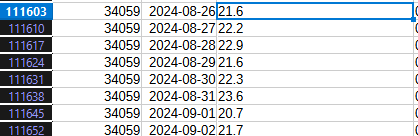

Скриншот из экселя, для проверки вручную

In [2432]:
# # --- Добавим колонку month_day для усреднения по дате без года ---
# train_df['month_day'] = train_df['date'].dt.strftime('%m-%d')
# val_df['month_day'] = val_df['date'].dt.strftime('%m-%d')
#
# # --- Историческая средняя по train_df для этих дней ---
# historical_mean = train_df.groupby('month_day')['Средняя температура воздуха'].mean()
#
# # --- Фактическая средняя по дню для val_df (учитываем несколько ВМО на день) ---
# val_daily = val_df.groupby('month_day')['Средняя температура воздуха'].mean()
#
# # --- Строим график ---
# plt.figure(figsize=(12, 6))
#
# # Фактическая температура
# plt.plot(val_daily.index, val_daily.values, label='Фактическая температура (val_df)', marker='o', color='orange')
#
# # Историческая средняя
# plt.plot(historical_mean.loc[val_daily.index].index, historical_mean.loc[val_daily.index].values,
#          label='Историческая средняя (train_df)', marker='x', color='blue')
#
# # Оформление
# plt.xticks(rotation=45)
# plt.xlabel('Дата (месяц-день)')
# plt.ylabel('Средняя температура воздуха')
# plt.title('Фактическая температура vs Историческая средняя')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Удаляем дату

In [2433]:
train_df = train_df.drop(columns=['date'])
val_df_drop_date = val_df.drop(columns=['date'])

### Отделяем целевой признак

In [2434]:
y_train = train_df['Средняя температура воздуха']
y_val = val_df_drop_date['Средняя температура воздуха']

# Признаки (оставляем Индекс ВМО)
X_train = train_df.drop(columns=['Средняя температура воздуха'])
X_val = val_df_drop_date.drop(columns=['Средняя температура воздуха'])

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)

Train shape: (111249, 10) (111249,)
Validation shape: (217, 10) (217,)


In [2435]:
print(X_train.isna().sum().sum())
print(y_train.isna().sum().sum())
print('Валидационное:')
print(X_val.isna().sum().sum())
print(y_val.isna().sum().sum())

0
0
Валидационное:
0
0


In [2436]:
X_train.columns

Index(['Индекс ВМО', 'year', 'day', 'day_of_year_sin', 'day_of_year_cos',
       'season', 'month_sin', 'month_cos',
       'Средняя температура воздуха_mean_group', 'temp_delta_vs_all_stations'],
      dtype='object')

## Предсказательные модели

| ugms               | name                  | kod   | широта     | долгота     |
|-------------------|----------------------|-------|-------|-------|
| ПРИВОЛЖСКОЕ УГМС  | САРАТОВ ЮГО-ВОСТОК   | 34172 | 51.57 | 46.0  |
| ПРИВОЛЖСКОЕ УГМС  | ОКТЯБРЬСКИЙ ГОРОДОК  | 34163 | 51.63 | 45.45 |
| ПРИВОЛЖСКОЕ УГМС  | РОСТАШИ              | 34059 | 51.87 | 43.58 |
| ПРИВОЛЖСКОЕ УГМС  | НОВОУЗЕНСК           | 34289 | 50.43 | 48.13 |
| ПРИВОЛЖСКОЕ УГМС  | АЛЕКСАНДРОВ ГАЙ      | 34391 | 50.15 | 48.55 |
| ПРИВОЛЖСКОЕ УГМС  | БАЛАШОВ              | 34152 | 51.55 | 43.15 |
| ПРИВОЛЖСКОЕ УГМС  | ЕРШОВ                | 34186 | 51.37 | 48.3  |

### Метрики оценки точности

#### Стандартные методы

In [2437]:
def simple_metric(y_val, y_pred):
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100
    r2 = r2_score(y_val, y_pred)

    print("Простые метрики:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}")
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

#### Ошибки по дням

In [2438]:
def daily_metrics(df_val, y_pred, date_col='date',
                  y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    df_val['prediction'] = y_pred
    results = []

    for date, group in df_val.groupby(date_col):
        y_true = group[y_true_col].values
        y_pred = group[y_pred_col].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        results.append({
            'date': date,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    return pd.DataFrame(results).sort_values('date')

#### Столбчатые диаграммы ошибок по индексам

In [2439]:
def metrics_per_index(df_val, y_pred, index_col='Индекс ВМО',
                      y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    """
    df_val: DataFrame с колонками y_true и индекс
    y_pred: массив предсказаний
    """
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    metrics_list = []

    for idx, group in df_val.groupby(index_col):
        y_true = group[y_true_col].values
        y_p = group[y_pred_col].values

        mae = mean_absolute_error(y_true, y_p)
        rmse = np.sqrt(mean_squared_error(y_true, y_p))
        r2 = r2_score(y_true, y_p)

        metrics_list.append({
            index_col: idx,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    metrics_df = pd.DataFrame(metrics_list).sort_values(index_col)

    # Строим графики
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    axes[0].bar(metrics_df[index_col].astype(str), metrics_df['MAE'], color='skyblue')
    axes[0].set_title('MAE по индексам')
    axes[0].set_ylabel('MAE (°C)')

    axes[1].bar(metrics_df[index_col].astype(str), metrics_df['RMSE'], color='salmon')
    axes[1].set_title('RMSE по индексам')
    axes[1].set_ylabel('RMSE (°C)')

    axes[2].bar(metrics_df[index_col].astype(str), metrics_df['R2'], color='lightgreen')
    axes[2].set_title('R² по индексам')
    axes[2].set_ylabel('R²')

    for ax in axes:
        ax.set_xlabel('Индекс ВМО')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return metrics_df

#### Линейный график MAE

In [2440]:
def cumulative_mae(df_val, y_pred, date_col='date',
                   y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    """
    df_val: DataFrame с колонками y_true и date
    y_pred: массив предсказаний
    """
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    # Сортируем по дате
    df_val = df_val.sort_values(date_col)

    # Копим MAE по дням
    cum_errors = []
    all_true = []
    all_pred = []

    for date, group in df_val.groupby(date_col):
        all_true.extend(group[y_true_col].values)
        all_pred.extend(group[y_pred_col].values)

        mae = mean_absolute_error(all_true, all_pred)
        cum_errors.append({'date': date, 'Cumulative_MAE': mae})

    cum_df = pd.DataFrame(cum_errors)

    # График
    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_MAE'], marker='o', linestyle='-')
    plt.xlabel('Дата')
    plt.ylabel('Кумулятивный MAE (°C)')
    plt.title('Накопление MAE по дням')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    return cum_df

#### Накопление ошибки Mae

In [2441]:
def cumulative_error(df_val, y_pred, date_col='date',
                     y_true_col='Средняя температура воздуха', y_pred_col='prediction'):
    df_val = df_val.copy()
    df_val[y_pred_col] = y_pred

    df_val = df_val.sort_values(date_col)

    cum_errors = []
    total_error = 0

    for date, group in df_val.groupby(date_col):
        daily_error = (group[y_true_col] - group[y_pred_col]).abs().sum()
        total_error += daily_error

        cum_errors.append({'date': date, 'Cumulative_Error': total_error})

    cum_df = pd.DataFrame(cum_errors)

    # График
    plt.figure(figsize=(12, 5))
    plt.plot(cum_df['date'], cum_df['Cumulative_Error'], marker='o')
    plt.xlabel('Дата')
    plt.ylabel('Накопленная ошибка')
    plt.title('Накопление абсолютной ошибки по дням')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    return cum_df

#### Сравнения истинной средней и предсказанной средней

In [2442]:
def plot_true_vs_pred(df_val, y_pred, date_col='date', y_true_col='Средняя температура воздуха'):
    df_plot = df_val.copy()
    df_plot['prediction'] = y_pred

    # Усредняем по индексам
    daily_true = df_plot.groupby(date_col)[y_true_col].mean()
    daily_pred = df_plot.groupby(date_col)['prediction'].mean()

    plt.figure(figsize=(12, 6))
    plt.plot(daily_true.index, daily_true.values, label='Истинная температура', marker='o', linestyle='-', color='blue')
    plt.plot(daily_pred.index, daily_pred.values, label='Предсказанная температура', marker='x', linestyle='--',
             color='orange')
    plt.xlabel('Дата')
    plt.ylabel('Температура (°C)')
    plt.title('Сравнение истинной и предсказанной температуры')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Сравнение истинной и предсказанной по индексам

In [2443]:
def plot_true_vs_pred_by_index(df_val, y_pred, date_col='date', index_col='Индекс ВМО',
                               y_true_col='Средняя температура воздуха'):
    df_plot = df_val.copy()
    df_plot['prediction'] = y_pred

    indices = df_plot[index_col].unique()
    n_indices = len(indices)

    # Определяем размер подграфиков (по 2 в ряду)
    n_cols = 2
    n_rows = (n_indices + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        ax = axes[i]
        df_idx = df_plot[df_plot[index_col] == idx]
        ax.plot(df_idx[date_col], df_idx[y_true_col], label='Истинная', marker='o', linestyle='-', color='blue')
        ax.plot(df_idx[date_col], df_idx['prediction'], label='Предсказанная', marker='x', linestyle='--',
                color='orange')
        ax.set_title(f'Индекс ВМО: {idx}')
        ax.grid(True, linestyle='--', alpha=0.5)
        if i % n_cols == 0:
            ax.set_ylabel('Температура (°C)')
        ax.legend(fontsize=8)

    # Скрываем лишние пустые графики
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### XGBRegressor

In [2444]:
# Создаем DMatrix для XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# Параметры модели
params = {
    'objective': 'reg:squarederror',  # регрессия
    'eval_metric': 'rmse',
    'eta': 0.1,  # learning rate
    'max_depth': 6,  # глубина деревьев
    'subsample': 0.8,  # случайная подвыборка для предотвращения переобучения
    'colsample_bytree': 0.8,
    'seed': 42
}

# Обучение с ранней остановкой
evals = [(dtrain, 'train'), (dval, 'validation')]
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=50
)

# Предсказание на валидации
y_pred = xgb_model.predict(dval)
xgb_result = simple_metric(y_val, y_pred)
xgb_result

[0]	train-rmse:11.54166	validation-rmse:11.45052
[50]	train-rmse:4.31685	validation-rmse:4.32231
[64]	train-rmse:4.20248	validation-rmse:4.32209
Простые метрики:
MAE: 3.5599
MSE: 18.6804
RMSE: 4.3221
MAPE: 19.07%
R²: -0.4178


{'MAE': 3.559923356579196,
 'MSE': 18.68044195261912,
 'RMSE': np.float64(4.32208768451302),
 'MAPE': np.float64(19.06592582882492),
 'R2': -0.4177946106648003}

In [2445]:
df_compare = pd.DataFrame({
    'y_true': y_val,
    'y_pred': y_pred
})

df_compare.head(5)

,y_true,y_pred
0,21.6,18.926720
1,22.2,17.491339
2,22.9,17.790663
3,21.6,18.038094
4,22.3,18.056402


#### Важность признаков


                                  feature    importance
8  Средняя температура воздуха_mean_group  95728.296875
4                         day_of_year_cos  17289.300781
5                                  season   5951.809082
6                               month_sin   2879.958496
3                         day_of_year_sin   2101.826904
1                                    year   1190.345581
7                               month_cos   1177.313232
2                                     day    538.988220
9              temp_delta_vs_all_stations    329.653564
0                              Индекс ВМО     29.924803


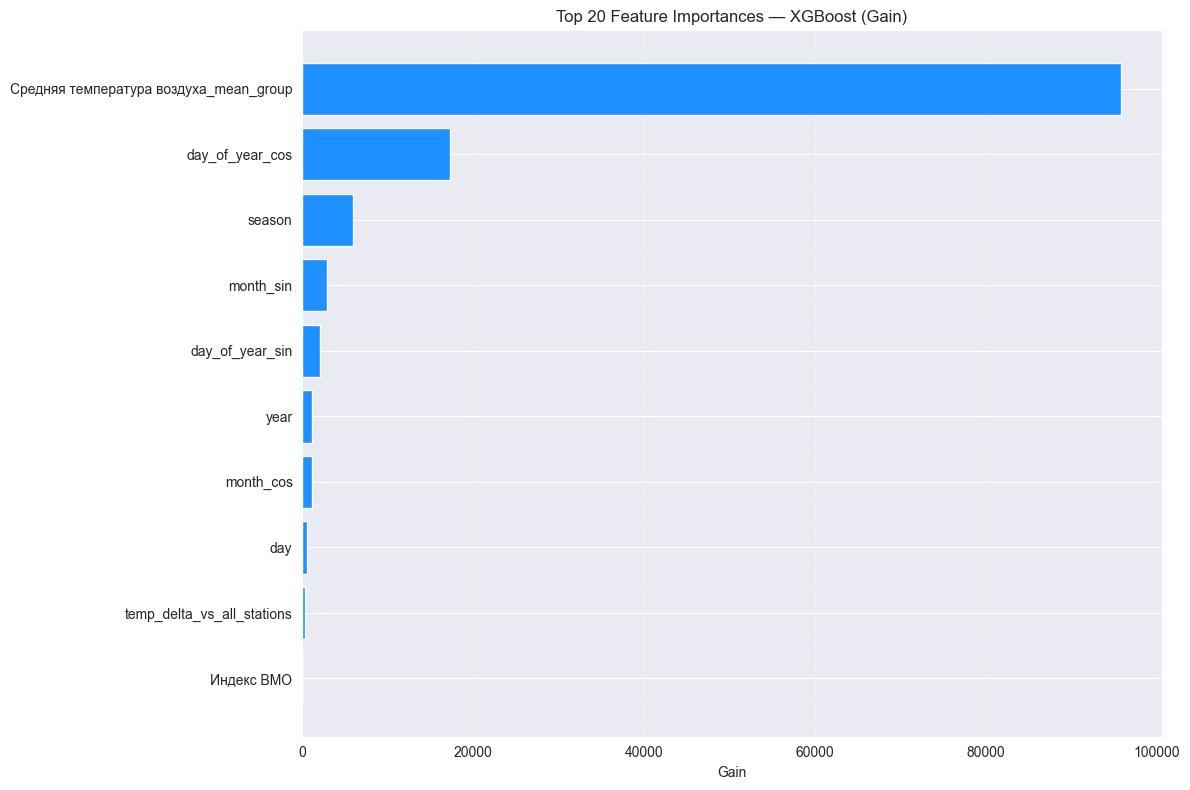

In [2446]:
gain_importances = xgb_model.get_score(importance_type='gain')

fi_df = pd.DataFrame({
    'feature': list(gain_importances.keys()),
    'importance': list(gain_importances.values())
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — XGBoost (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Оценка точности

In [2447]:
# daily_metrics(val_df, y_pred)

In [2448]:
# mae_index_df = metrics_per_index(val_df, y_pred)

Для Саратова хуже всего

In [2449]:
# cum_mae_df = cumulative_mae(val_df, y_pred)

In [2450]:
# cum_mae_df = cumulative_error(val_df, y_pred)

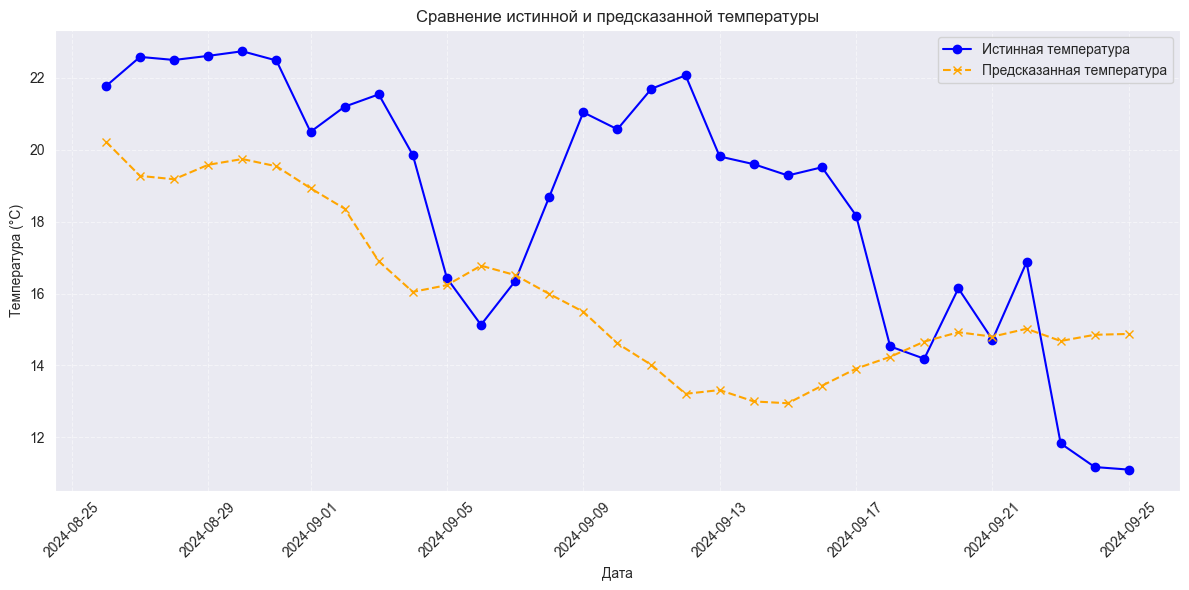

In [2451]:
plot_true_vs_pred(val_df, y_pred)

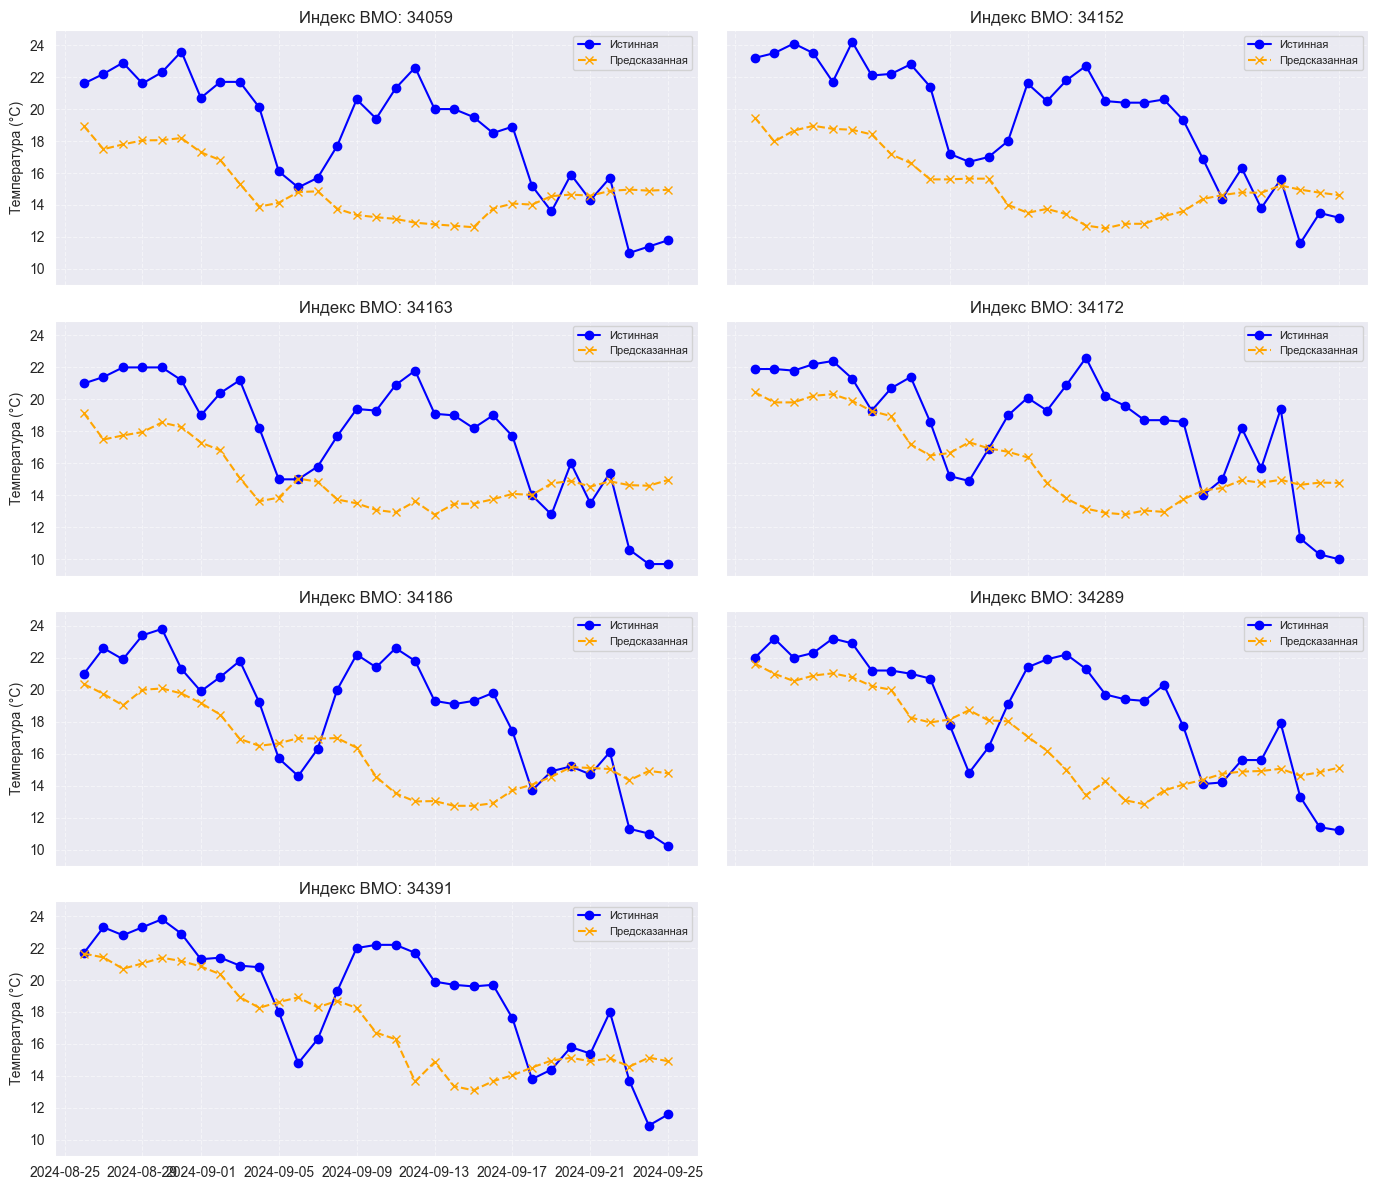

In [2452]:
plot_true_vs_pred_by_index(val_df, y_pred)

### LightGBM

In [2453]:
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

# Параметры (максимально близко к XGBoost)
params = {
    'objective': 'regression',  # аналог reg:squarederror
    'metric': 'rmse',
    'learning_rate': 0.1,  # eta
    'max_depth': 6,
    'feature_fraction': 0.8,  # colsample_bytree
    'bagging_fraction': 0.8,  # subsample
    'bagging_freq': 1,
    'seed': 42,
    'verbosity': -1
}

# Обучение с early stopping
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'validation'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=50)
    ]
)

# Предсказание
y_pred = model.predict(X_val, num_iteration=model.best_iteration)

# Метрика
lgb_result = simple_metric(y_val, y_pred)
lgb_result

Training until validation scores don't improve for 20 rounds
[50]	train's rmse: 4.46382	validation's rmse: 4.04507
Early stopping, best iteration is:
[47]	train's rmse: 4.48836	validation's rmse: 3.97948
Простые метрики:
MAE: 3.3952
MSE: 15.8362
RMSE: 3.9795
MAPE: 17.89%
R²: -0.2019


{'MAE': 3.3951907505027252,
 'MSE': 15.836242308027298,
 'RMSE': np.float64(3.9794776426093033),
 'MAPE': np.float64(17.89125424286892),
 'R2': -0.20192761255067682}

#### Важность признаков


                                  feature    importance
8  Средняя температура воздуха_mean_group  5.187689e+07
7                               month_cos  5.358477e+06
4                         day_of_year_cos  4.366306e+06
1                                    year  1.348911e+06
3                         day_of_year_sin  1.304590e+06
6                               month_sin  3.577390e+05
5                                  season  2.871396e+05
2                                     day  1.198435e+05
9              temp_delta_vs_all_stations  2.989815e+04
0                              Индекс ВМО  3.452225e+03


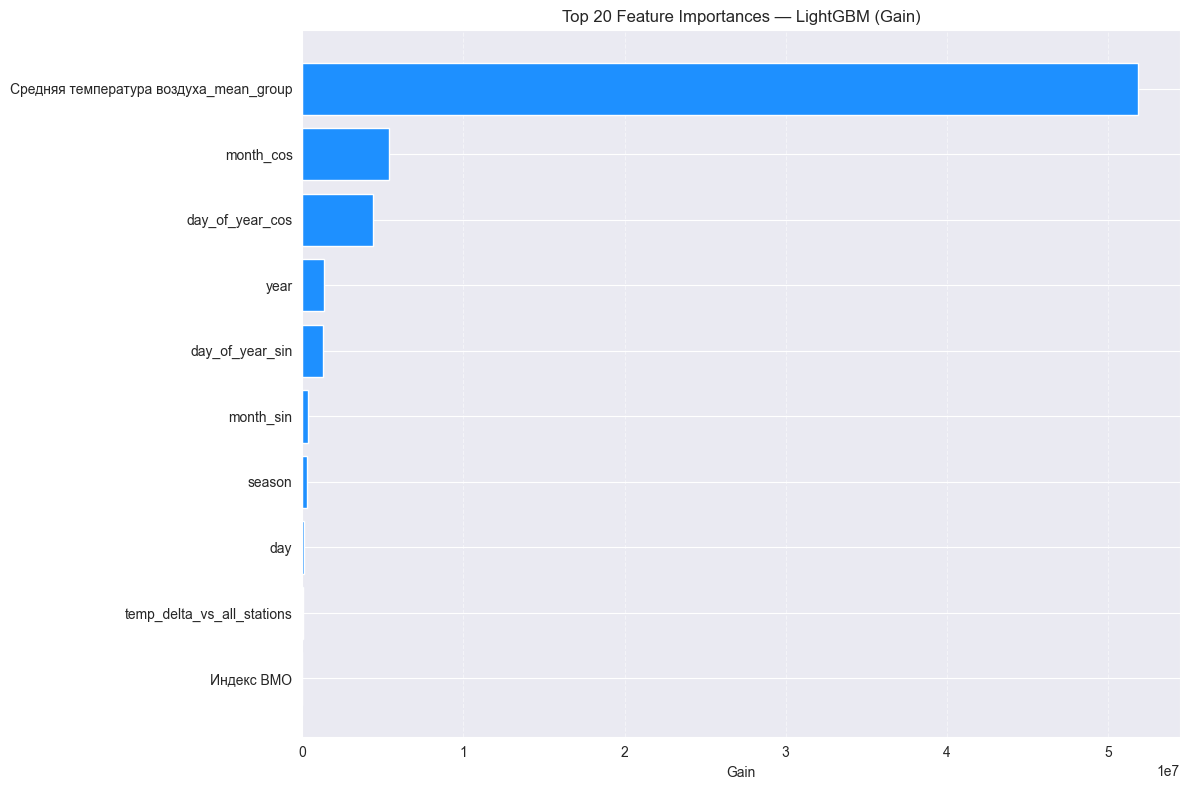

In [2454]:
# Получаем важность по gain
gain_importances = model.feature_importance(importance_type='gain')
feature_names = X_train.columns

# Создаём DataFrame
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gain_importances
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Gain')
plt.title('Top 20 Feature Importances — LightGBM (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### HistGradientBoostingRegressor

In [2455]:
model = HistGradientBoostingRegressor(
    loss='squared_error',
    learning_rate=0.1,
    max_depth=6,
    max_iter=500,
    max_bins=255,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.2,  # ← ВАЖНО
    random_state=42,
    verbose=1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

hist_result = simple_metric(y_val, y_pred)
hist_result

Binning 0.007 GB of training data: 0.028 s
Binning 0.002 GB of validation data: 0.004 s
Fitting gradient boosted rounds:
Fit 500 trees in 1.675 s, (15500 total leaves)
Time spent computing histograms: 0.421s
Time spent finding best splits:  0.153s
Time spent applying splits:      0.350s
Time spent predicting:           0.077s
Простые метрики:
MAE: 3.4134
MSE: 16.9858
RMSE: 4.1214
MAPE: 18.88%
R²: -0.2892


{'MAE': 3.4134113826979835,
 'MSE': 16.985802414565814,
 'RMSE': np.float64(4.121383555866381),
 'MAPE': np.float64(18.875796130220852),
 'R2': -0.2891760902804581}

### CatBoostRegressor

In [2456]:
# Модель (параметры максимально близки к XGBoost)
model = CatBoostRegressor(
    loss_function='RMSE',  # аналог reg:squarederror + rmse
    learning_rate=0.1,  # eta
    depth=6,  # аналог max_depth
    iterations=500,  # num_boost_round
    subsample=0.8,  # аналог subsample
    rsm=0.8,  # аналог colsample_bytree
    random_seed=42,
    verbose=50
)

# Обучение с early stopping
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=20,
    use_best_model=True
)

# Предсказание
y_pred = model.predict(X_val)

# Метрика
cat_result = simple_metric(y_val, y_pred)
cat_result

0:	learn: 11.5825348	test: 11.6170829	best: 11.6170829 (0)	total: 8.64ms	remaining: 4.31s
50:	learn: 4.7482392	test: 3.7643766	best: 3.7628921 (49)	total: 397ms	remaining: 3.5s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 3.535874533
bestIteration = 76

Shrink model to first 77 iterations.
Простые метрики:
MAE: 3.0404
MSE: 12.5024
RMSE: 3.5359
MAPE: 16.35%
R²: 0.0511


{'MAE': 3.040368321382306,
 'MSE': 12.502408614198535,
 'RMSE': np.float64(3.5358745190120273),
 'MAPE': np.float64(16.345320923530675),
 'R2': 0.05110127487885385}

#### Важность признаков

                                  feature  importance
8  Средняя температура воздуха_mean_group   46.180622
4                         day_of_year_cos   15.342493
1                                    year   12.210895
7                               month_cos    8.412536
5                                  season    7.047135
3                         day_of_year_sin    6.855719
6                               month_sin    2.295122
9              temp_delta_vs_all_stations    0.968215
2                                     day    0.629851
0                              Индекс ВМО    0.057410


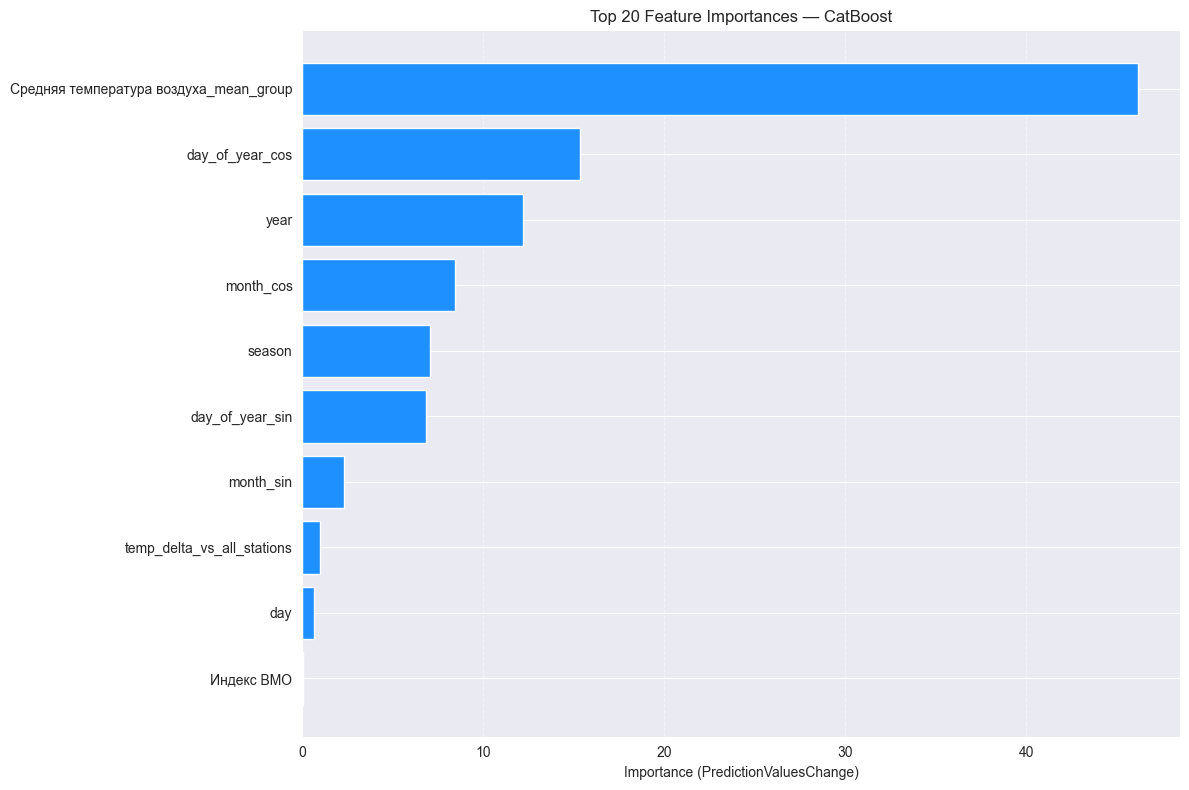

In [2457]:
# Получаем важность признаков по 'PredictionValuesChange' (аналог Gain)
gain_importances = model.get_feature_importance(type='PredictionValuesChange')
feature_names = X_train.columns

# Создаём DataFrame
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': gain_importances
}).sort_values(by='importance', ascending=False)

# Топ-20 признаков
fi_df_top20 = fi_df.head(20)
print(fi_df_top20)

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(fi_df_top20['feature'][::-1], fi_df_top20['importance'][::-1], color='dodgerblue')
plt.xlabel('Importance (PredictionValuesChange)')
plt.title('Top 20 Feature Importances — CatBoost')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### RandomForestRegressor

In [2458]:
# Модель (параметры максимально приближены по смыслу к XGBoost)
model = RandomForestRegressor(
    n_estimators=500,  # аналог num_boost_round (кол-во деревьев)
    max_depth=6,
    max_features=0.8,  # аналог colsample_bytree
    bootstrap=True,  # аналог subsample
    random_state=42,
    n_jobs=-1,  # использовать все ядра
    verbose=1
)

# Обучение
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_val)

rf_result = simple_metric(y_val, y_pred)
rf_result

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    6.1s


Простые метрики:
MAE: 3.5766
MSE: 17.7570
RMSE: 4.2139
MAPE: 18.97%
R²: -0.3477


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


{'MAE': 3.576570381159435,
 'MSE': 17.757038843022006,
 'RMSE': np.float64(4.213910160767788),
 'MAPE': np.float64(18.974502890618467),
 'R2': -0.34771083236991096}

## Результаты

In [2459]:
results = []

if 'xgb_result' in globals():
    results.append({'model': 'XGBoost', **xgb_result})

if 'lgb_result' in globals():
    results.append({'model': 'LightGBM', **lgb_result})

if 'hist_result' in globals():
    results.append({'model': 'HistGB', **hist_result})

if 'cat_result' in globals():
    results.append({'model': 'CatBoost', **cat_result})

if 'rf_result' in globals():
    results.append({'model': 'RandomForest', **rf_result})

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='MAE').reset_index(drop=True)

df_results

,model,MAE,MSE,RMSE,MAPE,R2
0,CatBoost,3.040368,12.502409,3.535875,16.345321,0.051101
1,LightGBM,3.395191,15.836242,3.979478,17.891254,-0.201928
2,HistGB,3.413411,16.985802,4.121384,18.875796,-0.289176
3,XGBoost,3.559923,18.680442,4.322088,19.065926,-0.417795
4,RandomForest,3.576570,17.757039,4.213910,18.974503,-0.347711


In [2460]:
df_results['MAE'][:3].sum()

np.float64(9.848970454583014)

In [2461]:
now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

with open("log.md", "a", encoding="utf-8") as f:
    f.write(f"\n\n## Run at {now}\n\n")
    f.write(df_results.to_markdown())
    f.write(f"\nПервые 3 MAE: {str(float(df_results['MAE'][:3].sum()))}")

## LSTM

In [2462]:
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense
# from tensorflow.keras.callbacks import EarlyStopping
#
# # 👉 Преобразуем данные в 3D (если они 2D)
# X_train_lstm = np.array(X_train)
# X_val_lstm = np.array(X_val)
#
# # если данные табличные (n_samples, n_features)
# X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], 1, X_train_lstm.shape[1])
# X_val_lstm = X_val_lstm.reshape(X_val_lstm.shape[0], 1, X_val_lstm.shape[1])
#
# # Модель
# model = Sequential([
#     LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
#     Dense(1)
# ])
#
# model.compile(
#     optimizer='adam',
#     loss='mse'
# )
#
# # Early stopping
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=20,
#     restore_best_weights=True
# )
#
# # Обучение
# history = model.fit(
#     X_train_lstm, y_train,
#     validation_data=(X_val_lstm, y_val),
#     epochs=500,
#     batch_size=32,
#     callbacks=[early_stop],
#     verbose=1
# )
#
# # Предсказание
# y_pred = model.predict(X_val_lstm).flatten()
#
# # Метрика
# lstm_result = simple_metric(y_val, y_pred)

In [2463]:
# import numpy as np
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Flatten
# from tensorflow.keras.callbacks import EarlyStopping
#
# # Преобразуем данные (как у тебя было)
# X_train_nn = np.array(X_train)
# X_val_nn = np.array(X_val)
#
# # добавляем фиктивную размерность (как будто timestep=1)
# X_train_nn = X_train_nn.reshape(X_train_nn.shape[0], 1, X_train_nn.shape[1])
# X_val_nn = X_val_nn.reshape(X_val_nn.shape[0], 1, X_val_nn.shape[1])
#
# # Модель (БЫСТРАЯ альтернатива LSTM)
# model = Sequential([
#     Flatten(input_shape=(1, X_train_nn.shape[2])),
#     Dense(64, activation='relu'),
#     Dense(32, activation='relu'),
#     Dense(1)
# ])
#
# model.compile(
#     optimizer='adam',
#     loss='mse'
# )
#
# # Early stopping
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=10,
#     restore_best_weights=True
# )
#
# # Обучение (значительно быстрее LSTM)
# history = model.fit(
#     X_train_nn, y_train,
#     validation_data=(X_val_nn, y_val),
#     epochs=100,
#     batch_size=64,
#     callbacks=[early_stop],
#     verbose=1
# )
#
# # Предсказание
# y_pred = model.predict(X_val_nn).flatten()
#
# # Метрика
# nn_result = simple_metric(y_val, y_pred)

In [2464]:
# import tensorflow as tf
# print(tf.config.list_physical_devices('GPU'))

In [2465]:
# import tensorflow as tf
#
# print("TF version:", tf.__version__)
# print("Built with CUDA:", tf.test.is_built_with_cuda())
# print("GPUs:", tf.config.list_physical_devices('GPU'))